# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Jessica Amihere
**Student ID:** 57592028

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [38]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

(41202, 13)

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


None

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
mta_tax,0


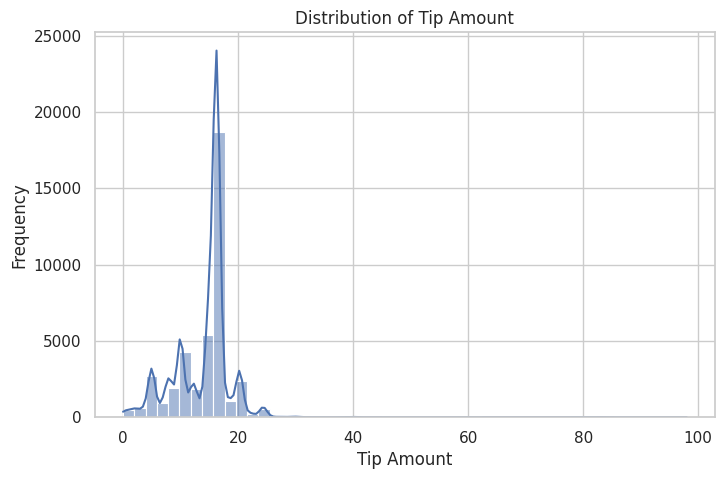

In [39]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
display(taxi.shape)
display(taxi.head())
display(taxi.info())
display(taxi.describe())
display(taxi.isna().sum())

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
plt.figure(figsize= (8,5))
sns.histplot(taxi["tip_amount"],bins=50, kde=True)

plt.title("Distribution of Tip Amount")
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")
plt.show()

**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:** i. shape- (41202, 13)
ii. No missing values
iii. It is right-skewed and has outliers
iv.


### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [40]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi= taxi.dropna(subset=["tip_amount"])

numeric_cols=taxi.select_dtypes(include="number").columns
for col in numeric_cols:
  taxi[col]=taxi[col].fillna(taxi[col].median())

categorical_cols=taxi.select_dtypes(include="number").columns

for col in categorical_cols:
  taxi[col]=taxi[col].fillna(taxi[col].mode())

taxi=taxi[taxi['trip_distance']>0]
taxi=taxi[taxi['fare_amount']>0]
taxi=taxi[taxi['tip_amount']>=0]

print((taxi['trip_distance']<=0).sum())
print((taxi['fare_amount']<=0).sum())
print((taxi['tip_amount']<0).sum())

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

taxi['fare_per_mile']=taxi['fare_amount']/taxi['trip_distance']
taxi['total_surcharges']=taxi['mta_tax']+taxi['tolls_amount']+taxi['improvement_surcharge']

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

categorical_cols=["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"]
numeric_cols= [col for col in taxi.columns if col not in categorical_cols]

taxi_encoded= pd.get_dummies(taxi,columns = categorical_cols, drop_first=True)
print(taxi_encoded.head())

# TODO: Separate features (X) and target (y = tip_amount
# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)


0
0
0
   passenger_count  trip_distance  PULocationID  DOLocationID  fare_amount  \
0                1          17.63           132           164         70.0   
1                1          19.52           132           236         70.0   
2                1          17.81           132            48         70.0   
3                2          19.30           132           148         70.0   
4                1          18.75           132           234         70.0   

   mta_tax  tolls_amount  improvement_surcharge  tip_amount  fare_per_mile  \
0      0.5          6.94                      1       16.54       3.970505   
1      0.5          6.94                      1       16.19       3.586066   
2      0.5          6.94                      1       12.00       3.930376   
3      0.5          0.00                      1        5.00       3.626943   
4      0.5          6.94                      1       10.00       3.733333   

   total_surcharges  RatecodeID_2  RatecodeID_4  Ratecod

**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:** [Double-click to edit]


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: Separate features (X) and target (y = tip_amount)
X=taxi.drop(columns=["tip_amount"])
Y=taxi["tip_amount"]

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
X_temp, X_test, y_temp, y_test = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_STATE)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)
X_test_scaled=scaler.transform(X_test)

**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:** A 60/20/20 split (Training/Validation/Test) is used so the validaton set can help improve the model while keeping the test set untouched for a fair final evaluation. The scaler should only be fitted in the training data to avoid data leakage.Using validation or test data would expose information the model should not see. This is similar to a student seeing test questions before the paper begins.

### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.


Linear Regression: 
Training RMSE:  4.804523924031085
Training R2:  0.05129977208869463
Validation RMSE:  5.036820301881184
Validation R2:  0.048754012892652465
Test RMSE:  5.014179073206695
Test R2:  0.05068338852223275

Random Forest: 
Training RMSE:  2.8369407074946364
Training R2:  0.05129977208869463
Validation RMSE:  5.646460320862078
Validation R2:  -0.19545294199443375
Test RMSE:  5.609765401212485
Test R2:  -0.1882307835530017


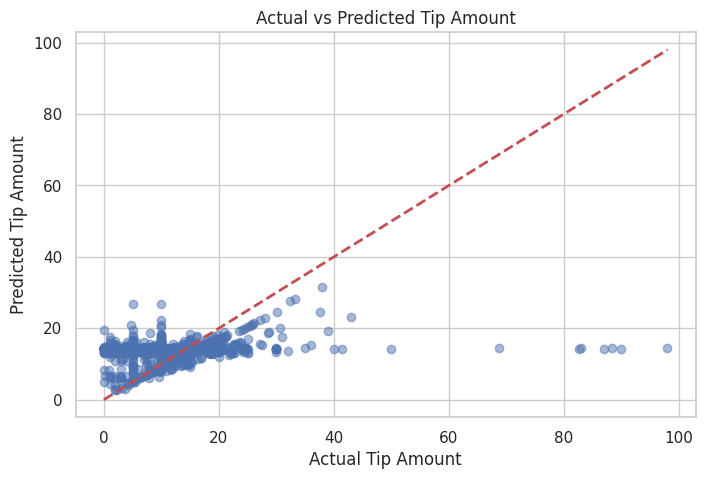

In [42]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train_scaled, y_train)

from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE
)
rf.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test sets.
y_prediction_lr=lr.predict(X_val_scaled)
y_prediction_rf=rf.predict(X_val_scaled)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
from sklearn.metrics import mean_squared_error, r2_score

y_train_pred=lr.predict(X_train_scaled)
y_val_pred=lr.predict(X_val_scaled)
y_test_pred=lr.predict(X_test_scaled)

y_train_pred_rf=rf.predict(X_train_scaled)
y_val_pred_rf=rf.predict(X_val_scaled)
y_test_pred_rf=rf.predict(X_test_scaled)

#For Linear Regression
train_rmse=mean_squared_error(y_train, y_train_pred) ** 0.5
train_r2_score=r2_score(y_train, y_train_pred)

val_rmse=mean_squared_error(y_val, y_val_pred) ** 0.5
val_r2_score=r2_score(y_val, y_val_pred)

test_rmse=mean_squared_error(y_test, y_test_pred) ** 0.5
test_r2_score=r2_score(y_test, y_test_pred)

#For Random Forest
train_rmse_rf=mean_squared_error(y_train, y_train_pred_rf) ** 0.5
train_r2_score_rf=r2_score(y_train, y_train_pred_rf)

val_rmse_rf=mean_squared_error(y_val, y_val_pred_rf) ** 0.5
val_r2_score_rf=r2_score(y_val,y_val_pred_rf)

test_rmse_rf=mean_squared_error(y_test, y_test_pred_rf) ** 0.5
test_r2_score_rf=r2_score(y_test, y_test_pred_rf)




print("\nLinear Regression: ")
print("Training RMSE: ", train_rmse)
print("Training R2: ", train_r2_score)
print("Validation RMSE: ", val_rmse)
print("Validation R2: ", val_r2_score)
print("Test RMSE: ", test_rmse)
print("Test R2: ", test_r2_score)

print("\nRandom Forest: ")
print("Training RMSE: ", train_rmse_rf)
print("Training R2: ", train_r2_score)
print("Validation RMSE: ", val_rmse_rf)
print("Validation R2: ", val_r2_score_rf)
print("Test RMSE: ", test_rmse_rf)
print("Test R2: ", test_r2_score_rf)

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize= (8,5))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
)
plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Actual vs Predicted Tip Amount")
plt.show()

**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:** [Double-click to edit]


---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

Shape:  (2111, 17)

First five rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                        

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing values per column:


,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


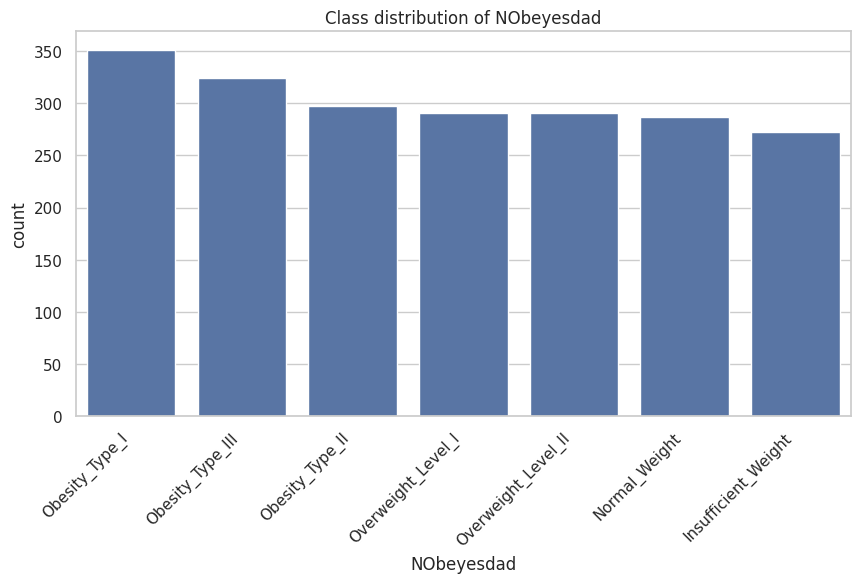

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity= pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
print("Shape: ", obesity.shape)

print("\nFirst five rows:")

display(obesity.head())

print("\nInfo:")
obesity.info()

print("\nSummary:")
display(obesity.describe())

print("\nMissing values per column:")
display(obesity.isna().sum())


# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?

print(obesity['NObeyesdad'].value_counts())

plt.figure(figsize =(10,5))
sns.countplot(data=obesity,x='NObeyesdad',order=obesity['NObeyesdad'].value_counts().index)
plt.xticks(rotation =45,ha='right')
plt.title('Class distribution of NObeyesdad')
plt.show()



**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:** [Double-click to edit]


### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [44]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

from sklearn.preprocessing import OrdinalEncoder

# Check actual unique values first to get the order right
print(obesity['CAEC'].unique())
print(obesity['CALC'].unique())

caec_order = ['no', 'Sometimes', 'Frequently', 'Always']
calc_order = ['no', 'Sometimes', 'Frequently', 'Always']

ordinal_encoder = OrdinalEncoder(categories=[caec_order, calc_order])
obesity[['CAEC','CALC']] = ordinal_encoder.fit_transform(obesity[['CAEC','CALC']])

nominal_cols = ['Gender', 'MTRANS']
obesity = pd.get_dummies(obesity, columns=nominal_cols, drop_first=True)

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity['BMI'] = obesity['Weight']/(obesity['Height'] ** 2)

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
obesity['NObeyesdad_encoded'] = label_encoder.fit_transform(obesity['NObeyesdad'])


# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
from sklearn.preprocessing import StandardScaler




['Sometimes' 'Frequently' 'Always' 'no']
['no' 'Sometimes' 'Frequently' 'Always']


**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:** [Double-click to edit]


### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [45]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
X = obesity.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'])
y = obesity['NObeyesdad_encoded']

X_scaled = scaler.fit_transform(X)

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.

from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(X_train.shape, X_val.shape, X_test.shape)

numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
numeric_cols = [c for c in numeric_cols if c in X_train.columns]


# TODO: Fit the scaler on the training set only, then transform train / val / test.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


(1477, 20) (317, 20) (317, 20)


**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:** [Double-click to edit]


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

Train: accuracy=1.0000, macro-F1=1.0000
Val: accuracy=0.9905, macro-F1=0.9904
Test: accuracy=0.9811, macro-F1=0.9802

Test classification report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        41
           1       0.93      0.98      0.95        43
           2       0.98      1.00      0.99        53
           3       1.00      1.00      1.00        45
           4       1.00      1.00      1.00        48
           5       0.96      1.00      0.98        43
           6       1.00      0.95      0.98        44

    accuracy                           0.98       317
   macro avg       0.98      0.98      0.98       317
weighted avg       0.98      0.98      0.98       317



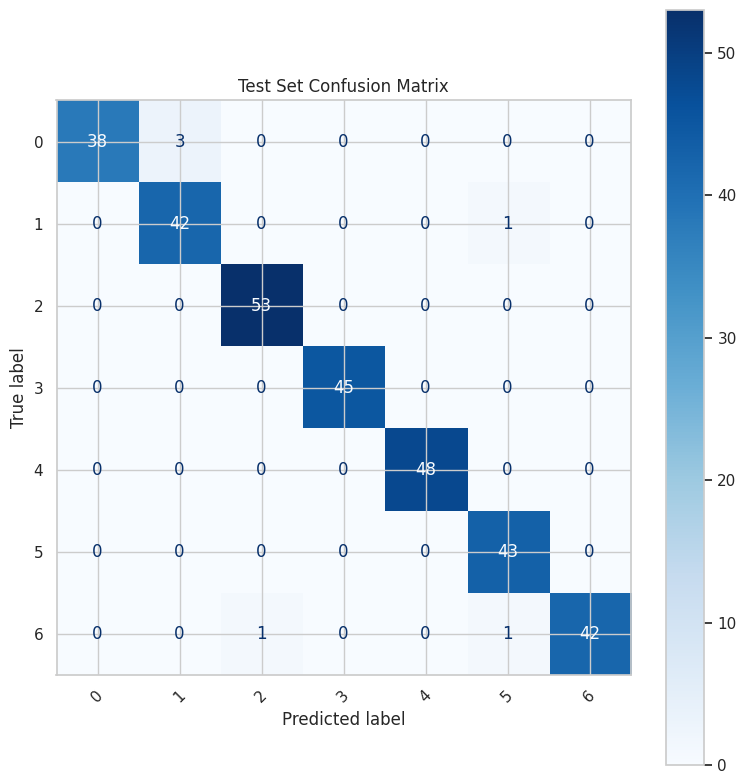

In [46]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# TODO: Predict on train, validation, and test.
clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
y_val_pred   = clf.predict(X_val)
y_test_pred  = clf.predict(X_test)


# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
for name, y_true, y_pred in [
    ("Train", y_train, y_train_pred),
    ("Val",   y_val,   y_val_pred),
    ("Test",  y_test,  y_test_pred),
]:
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    print(f"{name}: accuracy={acc:.4f}, macro-F1={f1m:.4f}")

print("\nTest classification report:")
print(classification_report(y_test, y_test_pred))

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()


**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:** [Double-click to edit]


---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


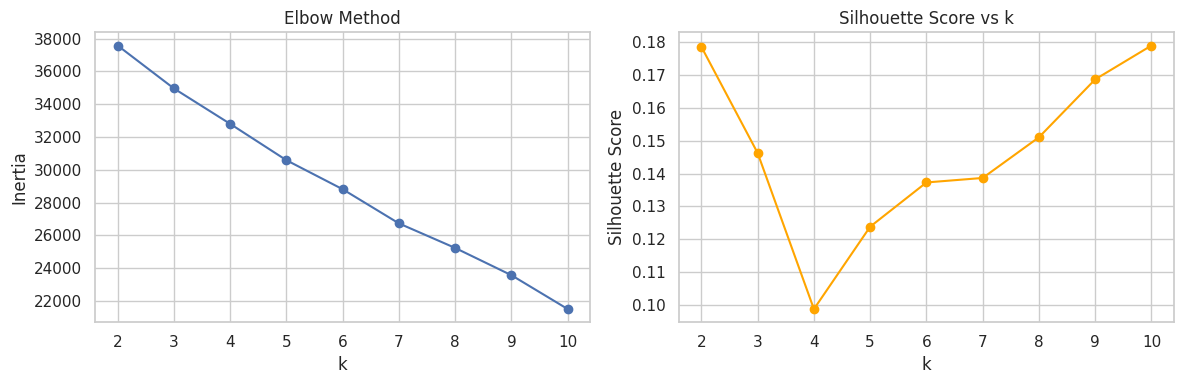

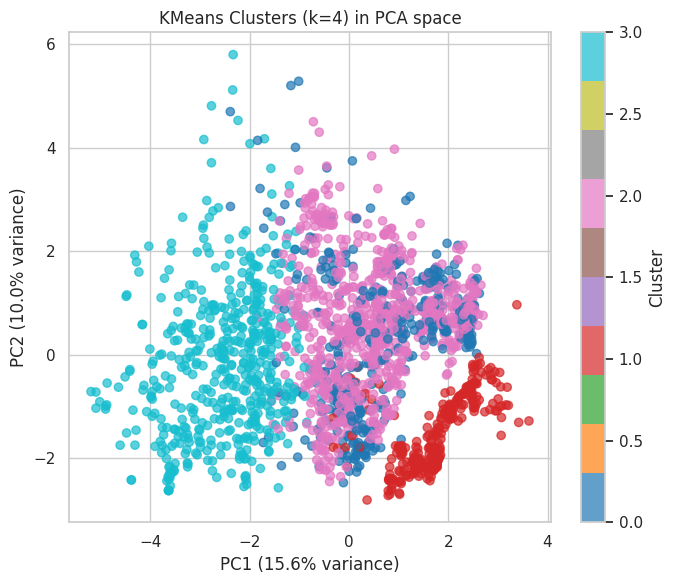

In [49]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_cluster = X_scaled

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, marker='o')
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(k_range, sil_scores, marker='o', color='orange')
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")
plt.tight_layout()
plt.show()


# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
k_chosen = 4
kmeans = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title(f"KMeans Clusters (k={k_chosen}) in PCA space")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()



In [50]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?

import pandas as pd

# Crosstab of cluster label vs true obesity category
crosstab = pd.crosstab(cluster_labels, obesity['NObeyesdad'])
print(crosstab)

# For each cluster, what fraction belongs to its most common true label?
purity = crosstab.max(axis=1) / crosstab.sum(axis=1)
print(purity)




NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
row_0                                                            
0                             1             31             114   
1                             0              0               8   
2                            75             66             225   
3                           196            190               4   

NObeyesdad  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
row_0                                                               
0                        98                 0                  63   
1                         3               324                   3   
2                       195                 0                 168   
3                         1                 0                  56   

NObeyesdad  Overweight_Level_II  
row_0                            
0                            98  
1                             3  
2                           136  
3                 

**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:** [Double-click to edit]


---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:** [Double-click to edit]


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
